# 02. Causal Modeling & Identification (DAG)
**Membuktikan Sebab-Akibat dalam Kesehatan: Estimasi Efek Kausal dari Data Observasional**

Fase 2 berfokus pada perumusan asumsi kausal secara formal menggunakan Directed Acyclic Graph (DAG) dan melakukan identifikasi estimand kausal menggunakan kerangka *Rubin Causal Model* via pustaka `DoWhy`.

Tujuan dari notebook ini adalah:
1. Membangun DAG formal yang menghubungkan Treatment (RHC), Outcome (Mortalitas 30 Hari), dan Confounders (68 variabel klinis & demografis).
2. Memvisualisasikan DAG secara bersih dan informatif.
3. Melakukan identifikasi efek kausal menggunakan kriteria *Backdoor* untuk menentukan set penyesuaian (*adjustment set*) yang valid.


In [1]:
# Import libraries
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as display

# Add src to python path
sys.path.append(os.path.abspath('../src'))
from dag import init_dowhy_model, identify_causal_effect
from plots import plot_dag


## 1. Memuat Data Ter-encode

In [2]:
# Load the encoded dataset
encoded_path = "../data/processed/rhc_encoded.csv"
df = pd.read_csv(encoded_path)
print(f"Loaded encoded dataset with shape: {df.shape}")


Loaded encoded dataset with shape: (5735, 79)


## 2. Visualisasi DAG

DAG plot saved to ../reports/figures/04_causal_dag.png


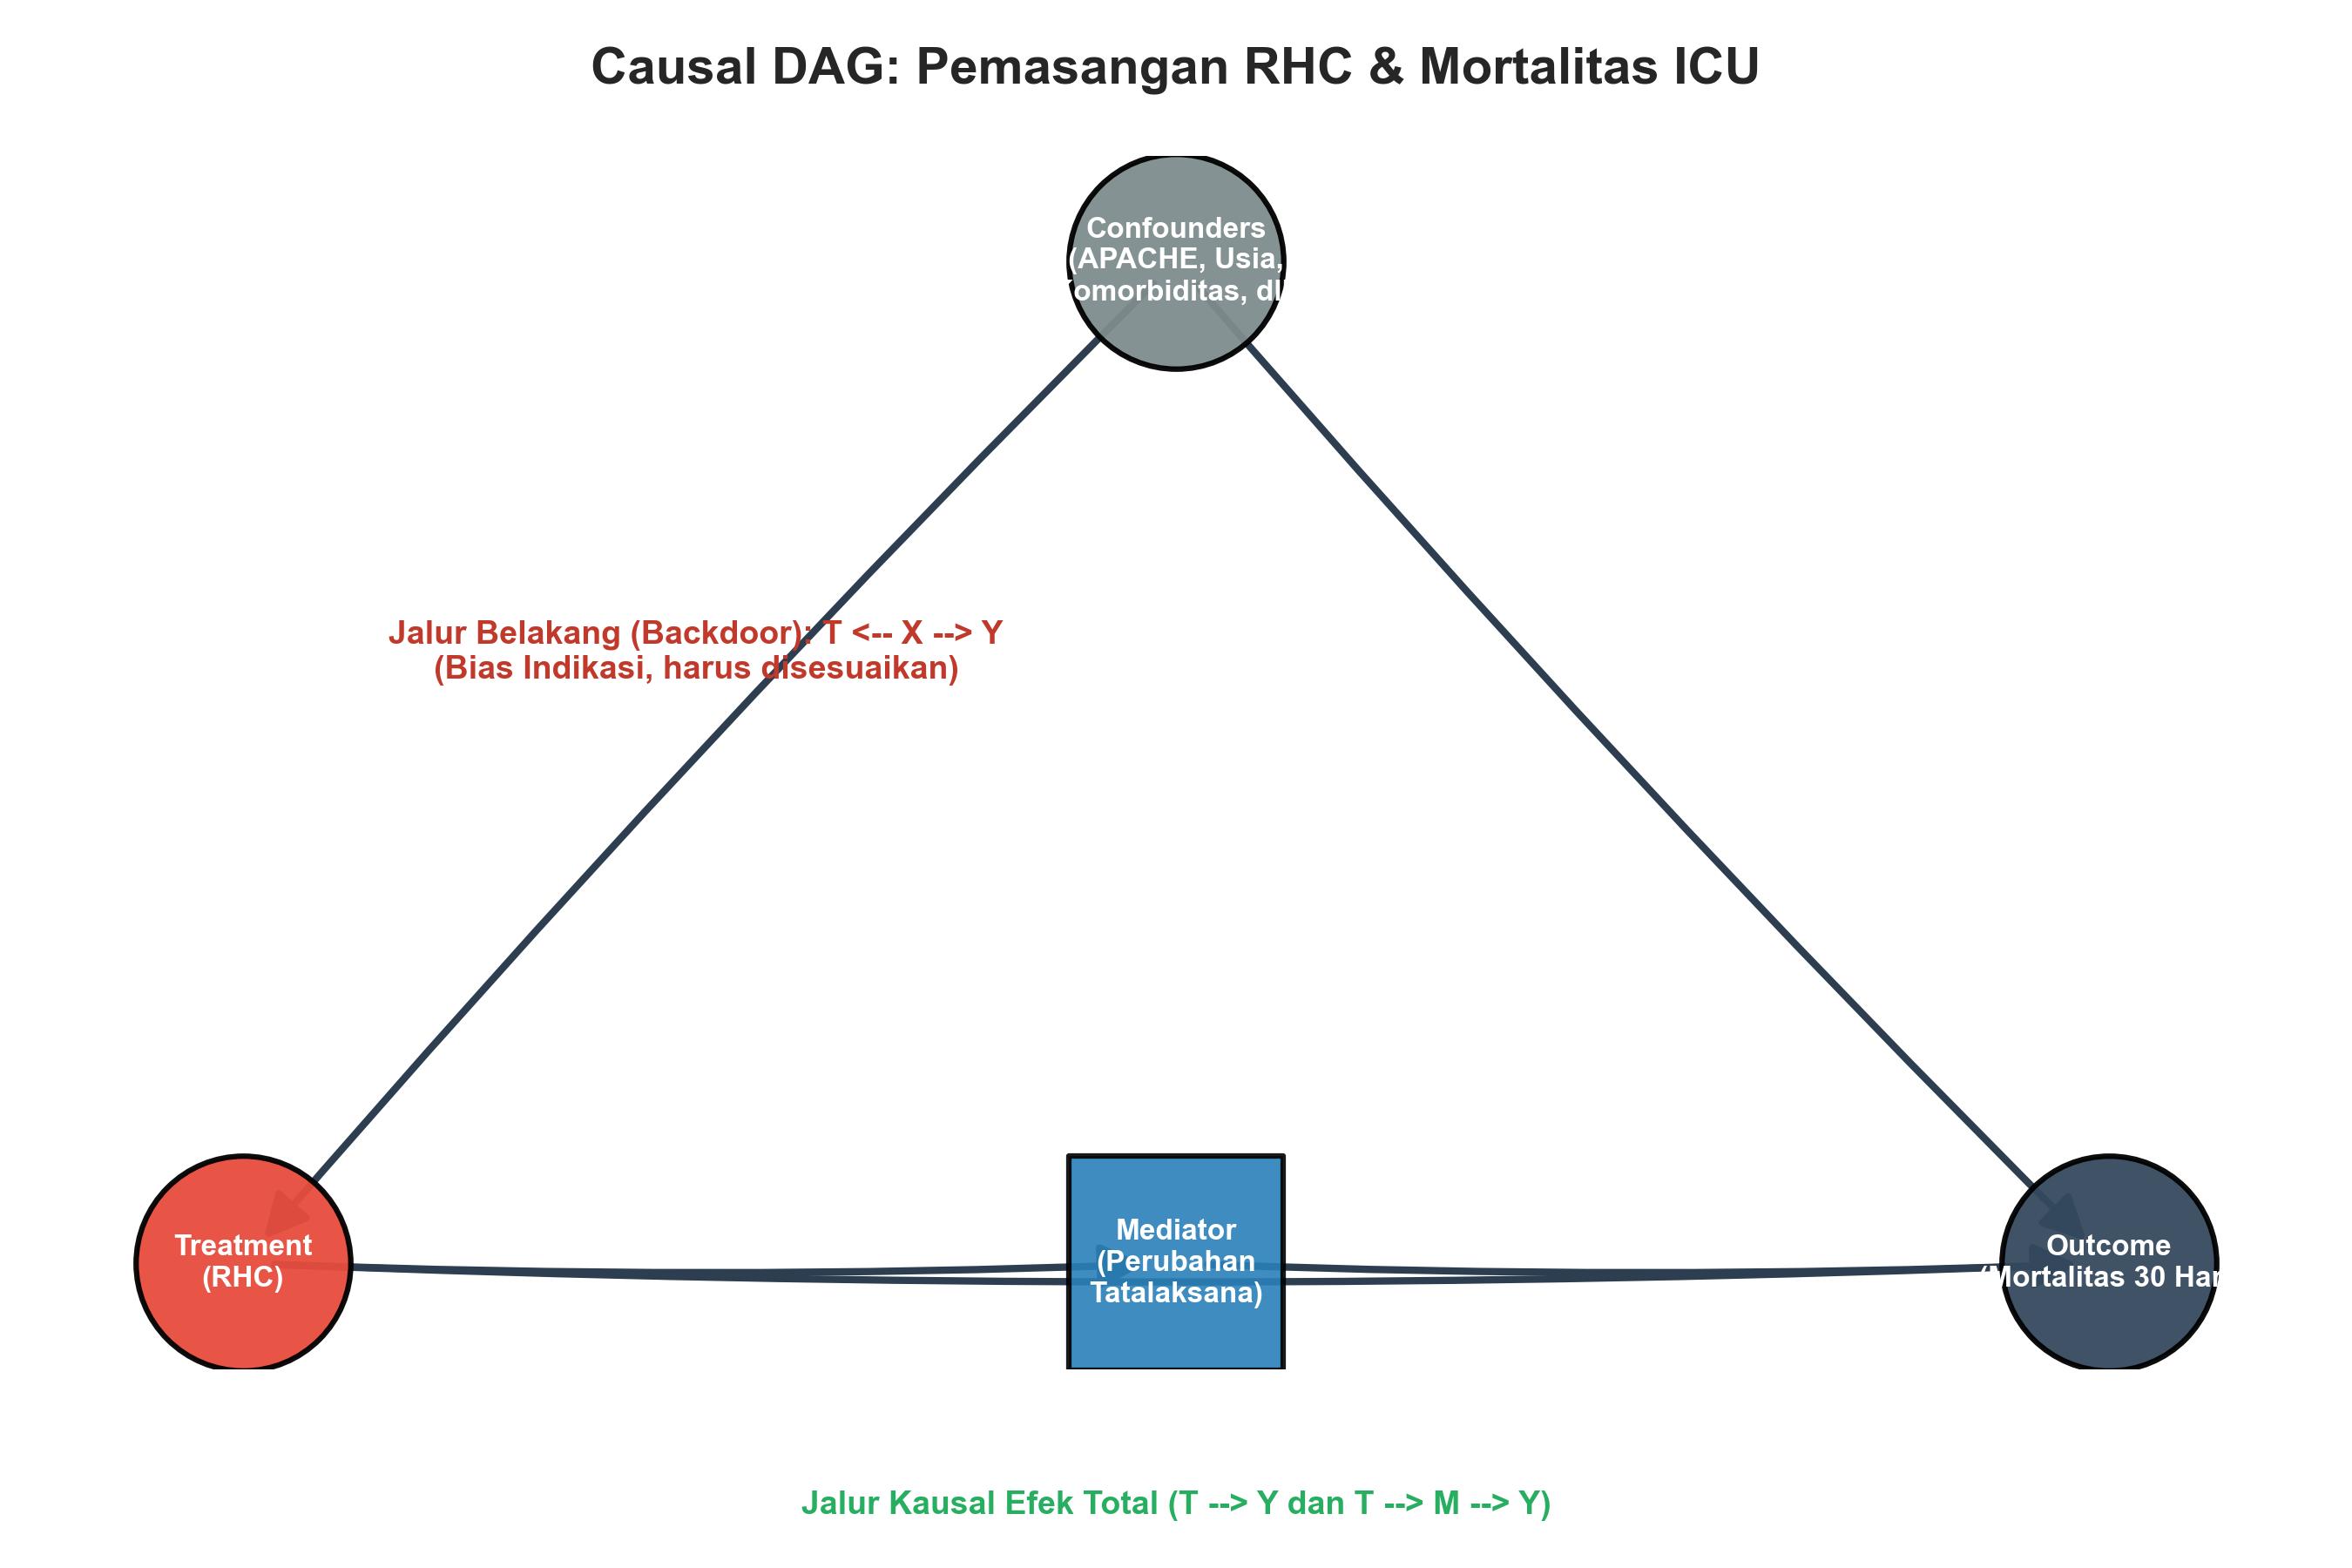

In [3]:
# Generate and plot the simplified Causal DAG
plot_dag(output_path="../reports/figures/04_causal_dag.png")

# Display the generated DAG plot
display.display(display.Image(filename="../reports/figures/04_causal_dag.png"))


## 3. Inisialisasi Model & Identifikasi Efek Kausal

In [4]:
# Initialize DoWhy CausalModel
model = init_dowhy_model(df, treatment='treatment', outcome='outcome')

# Run causal identification
estimand = identify_causal_effect(model)

print("\n--- HASIL IDENTIFIKASI ---")
try:
    print(estimand)
except UnicodeEncodeError:
    # Handle Windows terminal print issues
    print(str(estimand).encode('ascii', errors='replace').decode('ascii'))


Initializing DoWhy CausalModel with 68 confounders...
Identifying causal effect...


Causal effect identified successfully!

--- HASIL IDENTIFIKASI ---
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[outcome|scoma1,bili1,chfhx,alb1,age,paco21,temp1,hema1,ninsclas ↪
d[treatment]                                                                   ↪

↪                                                                              ↪
↪ _No insurance,wblc1,resp1,renal,cardiohx,pot1,gastr,resp,crea1,hema,hrt1,cat ↪
↪                                                                              ↪

↪                                                                              ↪
↪ 1_MOSF w/Sepsis,ph1,seps,wtkilo1,amihx,immunhx,card,aps1,ca,cat1_CHF,dnr1_Ye ↪
↪                                                                              ↪

↪                                                                              ↪
↪ s,chrpulh

### Analisis & Pembahasan Hasil Identifikasi:

1. **Estimand Teridentifikasi:**
   - DoWhy berhasil menemukan estimand **Backdoor** yang valid.
   - Pustaka mendeteksi bahwa efek kausal total dari `treatment` (RHC) terhadap `outcome` (mortalitas) dapat diidentifikasi secara unik dengan menyesuaikan (mengondisikan) seluruh 68 confounder yang diwariskan dari Fase 1.
   
2. **Asumsi Identifikasi Utama:**
   - **Unconfoundedness (Ignorability):** Diasumsikan tidak ada confounder tersembunyi yang tidak teramati (*unobserved confounders*) yang memengaruhi RHC dan mortalitas secara bersamaan. Jika asumsi ini terpenuhi, maka estimasi setelah penyesuaian akan mencerminkan efek kausal yang sebenarnya. (Asumsi ini akan diuji ketahanannya pada Fase 4 - Refutasi/Analisis Sensitivitas).
   - **Positivity (Overlap):** Diasumsikan setiap pasien memiliki peluang bukan nol untuk dipasang RHC maupun tidak dipasang RHC. (Akan kita periksa distribusi propensity score-nya di Fase 3).
